# Nucleus 1000 ins data to keypoints

In [90]:
import numpy as np
import pandas as pd
from tools.bag_to_df import bag_topic_to_dataframe
import matplotlib.pyplot as plt 
from tools.tools import *
from dataclasses import dataclass
from scipy.spatial.transform import Rotation as R

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [232]:
from tools.tools import print_bag_topics
bagdir = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
# bagdir = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-47-39_data.bag"
print_bag_topics(bagdir)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

In [233]:
ins_df = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/ins")
ins_df.head()

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


,t,__msgtype__,altitude,courseOverGround,declination,depth,fomAhrs,fomFc1,fomIns,header.__msgtype__,header.frame_id,header.seq,header.stamp.__msgtype__,header.stamp.nanosec,header.stamp.sec,latLonIsValid,latitude,longitude,operation_mode,positionFrame.__msgtype__,positionFrame.x,positionFrame.y,positionFrame.z,pressure,quaternion.__msgtype__,quaternion.w,quaternion.x,quaternion.y,quaternion.z,speedOverGround,temperature,turnRate.__msgtype__,turnRate.x,turnRate.y,turnRate.z,velocityNed.__msgtype__,velocityNed.x,velocityNed.y,velocityNed.z,velocityNucleus.__msgtype__,velocityNucleus.x,velocityNucleus.y,velocityNucleus.z
0,1.724330e+09,sensors/msg/Nucleus1000_ins,-1.0,80.266678,0.0,2.207257,0.509452,0.0,2.803900,std_msgs/msg/Header,NaN,1,builtin_interfaces/msg/Time,259438514,1724329751,False,0.0,0.0,2,geometry_msgs/msg/Vector3,1.238438,1.610469,2.205923,0.2219,geometry_msgs/msg/Quaternion,0.695266,-0.706343,-0.086223,0.101245,0.110084,15.609375,geometry_msgs/msg/Vector3,2.994492,-14.939211,-3.135995,geometry_msgs/msg/Vector3,0.018611,0.108499,-0.002420,geometry_msgs/msg/Vector3,0.046500,0.000075,0.099810
1,1.724330e+09,sensors/msg/Nucleus1000_ins,-1.0,81.819534,0.0,2.207257,0.508753,0.0,2.804440,std_msgs/msg/Header,NaN,2,builtin_interfaces/msg/Time,336195468,1724329751,False,0.0,0.0,2,geometry_msgs/msg/Vector3,1.240053,1.621326,2.205724,0.2219,geometry_msgs/msg/Quaternion,0.696195,-0.702794,-0.097281,0.109223,0.110099,15.609375,geometry_msgs/msg/Vector3,3.342670,-15.591107,-3.171875,geometry_msgs/msg/Vector3,0.015666,0.108979,-0.001591,geometry_msgs/msg/Vector3,0.046500,0.000075,0.099810
2,1.724330e+09,sensors/msg/Nucleus1000_ins,-1.0,92.968010,0.0,2.188357,0.507641,0.0,2.804978,std_msgs/msg/Header,NaN,3,builtin_interfaces/msg/Time,426952362,1724329751,False,0.0,0.0,2,geometry_msgs/msg/Vector3,1.239591,1.628189,2.181617,0.2200,geometry_msgs/msg/Quaternion,0.697745,-0.698385,-0.108501,0.116779,0.069365,15.609375,geometry_msgs/msg/Vector3,4.977259,-14.657893,-3.760612,geometry_msgs/msg/Vector3,-0.003592,0.069272,-0.067096,geometry_msgs/msg/Vector3,0.019163,0.066941,0.066821
3,1.724330e+09,sensors/msg/Nucleus1000_ins,-1.0,94.181534,0.0,2.188357,0.504891,0.0,2.805515,std_msgs/msg/Header,NaN,4,builtin_interfaces/msg/Time,519216537,1724329751,False,0.0,0.0,2,geometry_msgs/msg/Vector3,1.238968,1.635106,2.174943,0.2200,geometry_msgs/msg/Quaternion,0.699351,-0.693885,-0.118769,0.123795,0.069978,15.609375,geometry_msgs/msg/Vector3,4.110223,-13.548294,-2.528120,geometry_msgs/msg/Vector3,-0.005103,0.069792,-0.066456,geometry_msgs/msg/Vector3,0.019163,0.066941,0.066821
4,1.724330e+09,sensors/msg/Nucleus1000_ins,-1.0,95.378746,0.0,2.188357,0.502182,0.0,2.806051,std_msgs/msg/Header,NaN,5,builtin_interfaces/msg/Time,611538410,1724329751,False,0.0,0.0,2,geometry_msgs/msg/Vector3,1.238192,1.642064,2.168324,0.2200,geometry_msgs/msg/Quaternion,0.700356,-0.690024,-0.127475,0.130838,0.070452,15.609375,geometry_msgs/msg/Vector3,2.892454,-12.119763,-1.968699,geometry_msgs/msg/Vector3,-0.006604,0.070142,-0.065954,geometry_msgs/msg/Vector3,0.019163,0.066941,0.066821


In [234]:
dvl_position_df = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_position")
dvl_position_df.head()

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:212: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


,t,__msgtype__,format,header.__msgtype__,header.frame_id,header.seq,header.stamp.__msgtype__,header.stamp.nanosec,header.stamp.sec,pitch,roll,status,std,t_last_reset,time,x,y,yaw,z
0,1.724330e+09,sensors/msg/DVLPosition,json_v3.1,std_msgs/msg/Header,NaN,227,builtin_interfaces/msg/Time,623369216,1724329748,13.608875,0.223097,0,0.0,1.724330e+09,1.687102e+09,0.119364,0.015706,-1.359072,0.106320
1,1.724330e+09,sensors/msg/DVLPosition,json_v3.1,std_msgs/msg/Header,NaN,228,builtin_interfaces/msg/Time,883216857,1724329748,14.203016,0.515194,0,0.0,1.724330e+09,1.687102e+09,0.142463,0.016657,-1.278205,0.129368
2,1.724330e+09,sensors/msg/DVLPosition,json_v3.1,std_msgs/msg/Header,NaN,229,builtin_interfaces/msg/Time,94652414,1724329749,18.538614,0.694330,0,0.0,1.724330e+09,1.687102e+09,0.173816,0.019763,-1.027345,0.150828
3,1.724330e+09,sensors/msg/DVLPosition,json_v3.1,std_msgs/msg/Header,NaN,230,builtin_interfaces/msg/Time,322113513,1724329749,26.743727,0.938254,0,0.0,1.724330e+09,1.687102e+09,0.210177,0.014448,-1.195530,0.162825
4,1.724330e+09,sensors/msg/DVLPosition,json_v3.1,std_msgs/msg/Header,NaN,231,builtin_interfaces/msg/Time,554522037,1724329749,31.014429,1.023700,0,0.0,1.724330e+09,1.687102e+09,0.238665,0.006094,-0.979995,0.172385


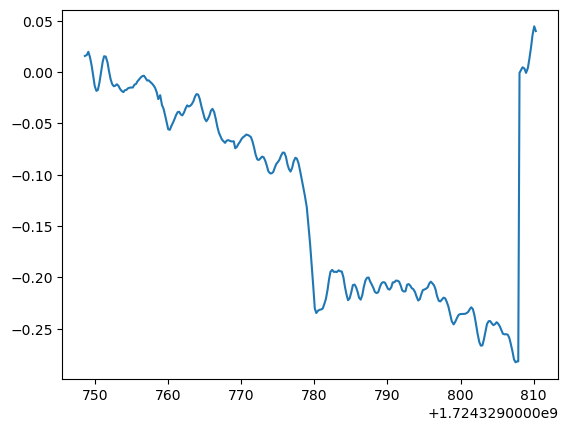

In [241]:
plt.plot(dvl_position_df["t"].values, dvl_position_df["y"].values)

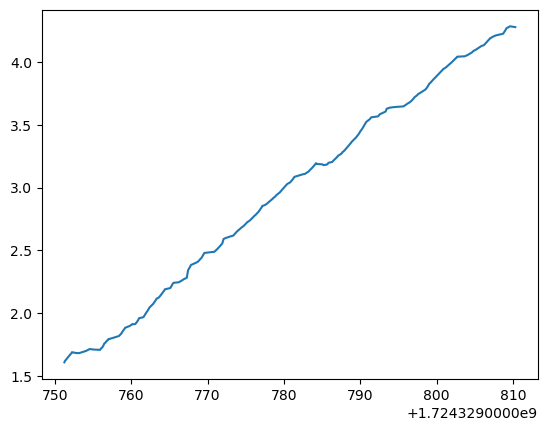

In [249]:
plt.plot(ins_df["t"].values, ins_df["positionFrame.y"].values)

x = ins_x
y = -ins_z
z = -ins_y


x_w = -ins_y
y_w = -ins_x
z_w = ins_Z

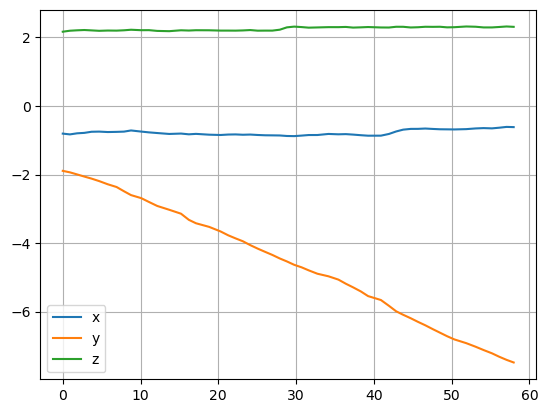

In [ ]:
#  Params
output_file = "keypoints.txt"
average_every = 10

# Post transformation
t_post = (0.0, 0.0, 0.0)
rpy_offset = (0.0, 0.0, 0.0)

# Avereage every
usable_len = (len(ins_df) // average_every) * average_every
ins_df = ins_df.iloc[:usable_len].copy()
groups = ins_df.groupby(ins_df.index // average_every, sort=True).mean(numeric_only=True)

# Start at t = 0
t0 = groups["t"].iloc[0]
groups["t"] -= t0


# Add roll pitch yaw columns
quats = groups[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
groups["roll"] = eulers[:, 0]
groups["pitch"] = eulers[:, 1]
groups["yaw"] = eulers[:, 2]

# Remove mean values. We are only interested in the variations
groups["roll"] -= groups["roll"].mean()
groups["pitch"] -= groups["pitch"].mean()
groups["yaw"] -= groups["yaw"].mean()


#Build keypoints
xyz_out, rpy_out, time_out = [], [], []

for i, row in groups.iterrows():
    # get current ins data
    x_pos = float(row["positionFrame.x"])
    y_pos = float(row["positionFrame.y"])
    z_pos = float(row["positionFrame.z"])

    roll = float(row["roll"])
    pitch = float(row["pitch"])
    yaw = float(row["yaw"])

    t = float(row["t"])


    # Map coordinates
    x_w = -y_pos
    y_w = -x_pos
    z_w = z_pos

    roll_w = -pitch
    pitch_w = -roll
    yaw_w = yaw


    # Rotate line around origin to match with simulated net

    P = np.array([x_w, y_w, z_w])
    axis = np.array([0, 0, 1])

    rot = R.from_rotvec(np.deg2rad(+30) * axis)

    rotated =  rot.apply(P)

    xyz_out.append((rotated[0], rotated[1], rotated[2]))


    # xyz_out.append((x_w, y_w, z_w))
    rpy_out.append((roll_w, pitch_w, yaw_w))
    time_out.append(t)

# Visualize path
x_list, y_list, z_list = [], [], []
for  x, y, z in xyz_out:
    x_list.append(x)
    y_list.append(y)
    z_list.append(z)

plt.plot(time_out, x_list, label="x")
plt.plot(time_out, y_list, label="y")
plt.plot(time_out, z_list, label="z")
plt.grid()
plt.legend()

In [267]:
# To file
fmt = lambda v: f"{v:.4f}"
lines = []
for t, xyz, rpy in zip(time_out, xyz_out, rpy_out):
    line = (
        f'<keypoint time="{fmt(t)}" '
        f'xyz="{" ".join(fmt(v) for v in xyz)}" '
        f'rpy="{" ".join(fmt(v) for v in rpy)}"/>'
    )
    lines.append(line)

with open(output_file, "w") as f:
    f.write("\n".join(lines))

print(f"Wrote {len(lines)} keypoints to {output_file}")


Wrote 56 keypoints to keypoints.txt
